In [ ]:
import marimo as mo
import time
import os
import torch
import numpy as np
from sklearn.metrics import classification_report


In [ ]:
from datasets import load_dataset
from torch.utils.data import DataLoader
import timm
from timm.data import resolve_model_data_config, create_transform

# --- 1. SETUP TRANSFORMS ---
PRETRAIN_MODEL = "vit_base_patch16_224"
data_cfg = resolve_model_data_config(timm.create_model(PRETRAIN_MODEL, pretrained=False))
mean, std = data_cfg["mean"], data_cfg["std"]

train_transform = create_transform(
    input_size=224, is_training=True, mean=mean, std=std,
    auto_augment="rand-m7-mstd0.5-inc1", re_prob=0.25, re_mode="pixel", re_count=1
)
eval_transform = create_transform(
    input_size=224, is_training=False, mean=mean, std=std, crop_pct=0.875
)

# --- 2. DOWNLOAD & SHRINK ---
print("Downloading EmoSet-118K...")
full_data = load_dataset("Woleek/EmoSet-118K", split="train")

print("Shrinking to a 10% Mini-EmoSet...")
mini_dataset = full_data.train_test_split(train_size=0.10, stratify_by_column="label")['train']

# --- 3. CREATE THE 80 / 10 / 10 SPLIT ---
print("Creating balanced Train / Val / Test splits...")

split_1 = mini_dataset.train_test_split(test_size=0.20, stratify_by_column="label")
mini_train = split_1['train']
temp_test = split_1['test']

split_2 = temp_test.train_test_split(test_size=0.50, stratify_by_column="label")
mini_val = split_2['train']
mini_test = split_2['test']

print(f"Train Images: {len(mini_train)}")
print(f"Val Images:   {len(mini_val)}")
print(f"Test Images:  {len(mini_test)}")

# --- 4. APPLY TRANSFORMS (returns pixel_values; image column stays for re-entry) ---
def apply_train_transforms(examples):
    examples["pixel_values"] = [train_transform(img.convert("RGB")) for img in examples["image"]]
    return examples

def apply_val_transforms(examples):
    examples["pixel_values"] = [eval_transform(img.convert("RGB")) for img in examples["image"]]
    return examples

mini_train = mini_train.with_transform(apply_train_transforms)
mini_val = mini_val.with_transform(apply_val_transforms)
mini_test = mini_test.with_transform(apply_val_transforms)

# --- 5. CUSTOM COLLATE: pull only pixel_values + label from each sample ---
def collate_pixels(batch):
    pixel_values = torch.stack([item["pixel_values"] for item in batch])
    labels = torch.tensor([item["label"] for item in batch], dtype=torch.long)
    return {"pixel_values": pixel_values, "label": labels}

# --- 6. CREATE DATALOADERS ---
BATCH_SIZE = 64
NUM_WORKERS = 0

train_loader = DataLoader(
    mini_train, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_pixels,
)
val_loader = DataLoader(
    mini_val, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_pixels,
)
test_loader = DataLoader(
    mini_test, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_pixels,
)

print("\nDataLoaders ready! You can now run your model training.")

Shrinking to a 10% Mini-EmoSet...
Train Images: 7558
Val Images:   945
Test Images:  945

DataLoaders ready!


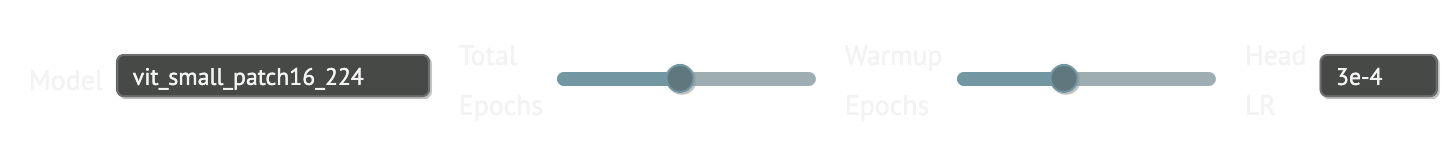

In [ ]:
epochs = mo.ui.slider(1, 20, value=5, label="Epochs")
learning_rate = mo.ui.dropdown(
    options=["1e-4", "3e-4", "5e-4", "1e-3"],
    value="3e-4",
    label="Learning Rate",
)
mo.hstack([epochs, learning_rate])

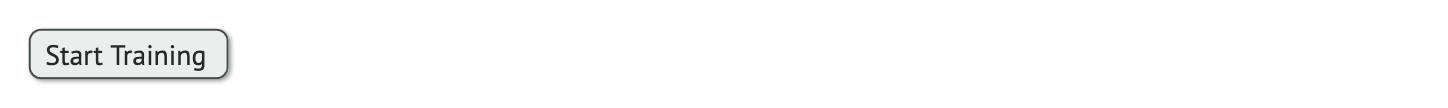

In [ ]:
train_button = mo.ui.run_button(label="Start Training")
train_button

In [ ]:
EMOTION_LABELS = [
    "amusement",
    "awe",
    "contentment",
    "excitement",
    "anger",
    "disgust",
    "fear",
    "sadness"
]

NUM_CLASSES = len(EMOTION_LABELS)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = timm.create_model(PRETRAIN_MODEL, pretrained=True, num_classes=NUM_CLASSES)
model = model.to(device)

_labels = [mini_train[i]['label'] for i in range(len(mini_train))]
_counts = np.bincount(_labels, minlength=NUM_CLASSES)
class_weights = torch.tensor(len(_labels) / (NUM_CLASSES * _counts), dtype=torch.float32).to(device)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

Model: vit_small_patch16_224 (compiled)
Device: cuda


In [ ]:
mo.stop(not train_button.value, mo.md("Click the button above to start training."))

_lr = float(learning_rate.value)
_epochs = epochs.value
optimizer = torch.optim.AdamW(model.parameters(), lr=_lr, weight_decay=0.05)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=_epochs)
scaler = torch.amp.GradScaler()

train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_loss = float("inf")
best_state = None

for _epoch in range(_epochs):
    model.train()
    _running_loss, _correct, _total = 0.0, 0, 0
    for _batch in train_loader:
        _imgs = _batch["pixel_values"].to(device)
        _labels = _batch["label"].to(device)
        optimizer.zero_grad()
        with torch.amp.autocast("cuda"):
            _outputs = model(_imgs)
            _loss = criterion(_outputs, _labels)
        scaler.scale(_loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        _running_loss += _loss.item() * _imgs.size(0)
        _correct += (_outputs.argmax(1) == _labels).sum().item()
        _total += _labels.size(0)
    scheduler.step()
    train_losses.append(_running_loss / _total)
    train_accs.append(_correct / _total)

    model.eval()
    _vloss, _vcorrect, _vtotal = 0.0, 0, 0
    with torch.no_grad():
        for _batch in val_loader:
            _imgs = _batch["pixel_values"].to(device)
            _labels = _batch["label"].to(device)
            with torch.amp.autocast("cuda"):
                _outputs = model(_imgs)
                _loss = criterion(_outputs, _labels)
            _vloss += _loss.item() * _imgs.size(0)
            _vcorrect += (_outputs.argmax(1) == _labels).sum().item()
            _vtotal += _labels.size(0)
    val_losses.append(_vloss / _vtotal)
    val_accs.append(_vcorrect / _vtotal)

    print(f"Epoch {_epoch+1}/{_epochs} | "
          f"Train Loss: {train_losses[-1]:.4f} Acc: {train_accs[-1]:.4f} | "
          f"Val Loss: {val_losses[-1]:.4f} Acc: {val_accs[-1]:.4f}")

    if val_losses[-1] < best_val_loss:
        best_val_loss = val_losses[-1]
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

model.load_state_dict(best_state)
mo.md(f"**Training complete.** Best val loss: {best_val_loss:.4f}")

=== Phase 1: Warmup (frozen backbone, head only) ===
Warmup Epoch 1/2 | Train Loss: 1.6588 Acc: 0.4001 | Val Loss: 1.0909 Acc: 0.6138
Warmup Epoch 2/2 | Train Loss: 1.1646 Acc: 0.5894 | Val Loss: 0.9582 Acc: 0.6550

=== Phase 2: Fine-tune (unfrozen, differential LR) ===
Finetune Epoch 1/8 | Train Loss: 0.9581 Acc: 0.6503 | Val Loss: 0.7366 Acc: 0.7259
Finetune Epoch 2/8 | Train Loss: 0.7832 Acc: 0.7108 | Val Loss: 0.6877 Acc: 0.7429
Finetune Epoch 3/8 | Train Loss: 0.6992 Acc: 0.7397 | Val Loss: 0.6715 Acc: 0.7672
Finetune Epoch 4/8 | Train Loss: 0.6404 Acc: 0.7622 | Val Loss: 0.6743 Acc: 0.7534
Finetune Epoch 5/8 | Train Loss: 0.5826 Acc: 0.7830 | Val Loss: 0.6684 Acc: 0.7577
Finetune Epoch 6/8 | Train Loss: 0.5532 Acc: 0.7976 | Val Loss: 0.6689 Acc: 0.7608
Finetune Epoch 7/8 | Train Loss: 0.5283 Acc: 0.8014 | Val Loss: 0.6613 Acc: 0.7630
Finetune Epoch 8/8 | Train Loss: 0.5180 Acc: 0.8092 | Val Loss: 0.6626 Acc: 0.7640


<span class="markdown prose dark:prose-invert contents"><span class="paragraph"><strong>Training complete.</strong> Best val loss: 0.6613 | Final val acc: 0.7640</span></span>

In [ ]:
mo.stop(not train_button.value, mo.md("Train the model first."))

model.eval()
_all_preds, _all_labels = [], []
with torch.no_grad():
    for _batch in test_loader:
        _imgs = _batch["pixel_values"].to(device)
        _labels = _batch["label"]
        with torch.amp.autocast("cuda"):
            _outputs = model(_imgs)
        _all_preds.extend(_outputs.argmax(1).cpu().numpy())
        _all_labels.extend(_labels.numpy())

_all_preds = np.array(_all_preds)
_all_labels = np.array(_all_labels)

print(classification_report(_all_labels, _all_preds, target_names=EMOTION_LABELS))

              precision    recall  f1-score   support

   amusement       0.22      0.17      0.19       157
         awe       0.38      0.17      0.24       120
 contentment       0.11      0.21      0.14       131
  excitement       0.04      0.02      0.03       158
       anger       0.00      0.00      0.00        84
     disgust       0.12      0.29      0.17        85
        fear       0.04      0.03      0.03       108
     sadness       0.09      0.13      0.11       102

    accuracy                           0.13       945
   macro avg       0.13      0.13      0.11       945
weighted avg       0.13      0.13      0.12       945

